<a href="https://colab.research.google.com/github/MinyaevAndrey/MYPETS/blob/main/TensorFlow_Model_Optimization_Toolkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

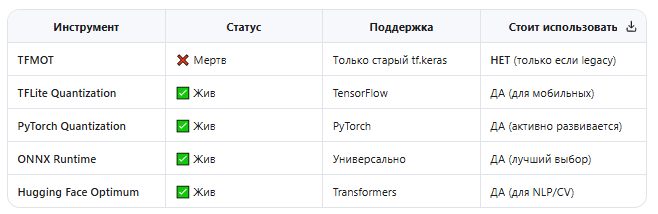

In [1]:
import tensorflow as tf

(images, labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def delDir(dir_str):
    """Удаление директории с логами"""
    if os.path.exists(dir_str):
        shutil.rmtree(dir_str)
        print("Каталог успешно удален")
    else:
        print("Каталог не существует")

#Стандартное обучение без выкрутасов

In [ ]:

def get_mnist_model():
    inputs = tf.keras.layers.Input(shape=(28 * 28,))
    features = tf.keras.layers.Dense(512, activation="relu")(inputs)
    features = tf.keras.layers.Dropout(0.5)(features)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(features)
    model = tf.keras.models.Model(inputs, outputs)
    return model



model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9130 - loss: 0.2915 - val_accuracy: 0.9599 - val_loss: 0.1430
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9549 - loss: 0.1492 - val_accuracy: 0.9679 - val_loss: 0.1040
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9639 - loss: 0.1155 - val_accuracy: 0.9714 - val_loss: 0.0912
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0831
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#TFLite

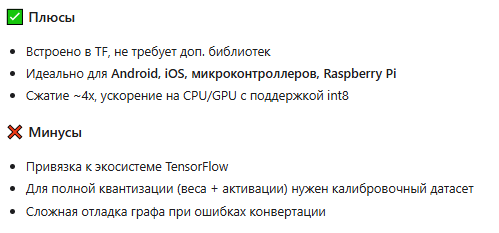

In [2]:
import numpy as np
import time

# ============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================================
print("=" * 60)
print("ШАГ 1: Загрузка данных MNIST")
print("=" * 60)

(images, labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Нормализация: пиксели [0, 255] → [0.0, 1.0]
# Reshape: 28×28 → 784 (плоский вектор)
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

# Разделение на train/val: 50k train, 10k val
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

print(f"✓ Train: {len(train_images)} примеров")
print(f"✓ Val: {len(val_images)} примеров")
print(f"✓ Test: {len(test_images)} примеров")

# ============================================================================
# 2. ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ
# ============================================================================
def get_mnist_model():
    """
    Создаёт простую нейросеть для классификации MNIST:
    Input(784) → Dense(512, ReLU) → Dropout(0.5) → Dense(10, Softmax)
    """
    inputs = tf.keras.layers.Input(shape=(28 * 28,))
    features = tf.keras.layers.Dense(512, activation="relu")(inputs)
    features = tf.keras.layers.Dropout(0.5)(features)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(features)
    return tf.keras.models.Model(inputs, outputs)

# ============================================================================
# 3. ОБУЧЕНИЕ МОДЕЛИ (FLOAT32)
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 2: Обучение модели (float32)")
print("=" * 60)

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Обучаем 3 эпохи с валидацией
history = model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
    verbose=1
)

# Оцениваем точность оригинальной модели на тесте
original_accuracy = model.evaluate(test_images, test_labels, verbose=0)[1]
print(f"\n✓ Точность оригинальной модели (float32): {original_accuracy*100:.2f}%")

# ============================================================================
# 4. КАЛИБРОВОЧНЫЙ ДАТАСЕТ ДЛЯ ПОЛНОЙ КВАНТИЗАЦИИ
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 3: Подготовка калибровочного датасета")
print("=" * 60)

def representative_dataset():
    """
    Генератор калибровочных данных для полной int8 квантизации.

    Зачем это нужно:
    - При квантизации весов (weight-only) TFLite сам вычисляет scale/zero_point
    - При квантизации активаций нужно знать их диапазон значений
    - Для этого прогоняем 100-1000 примеров через модель и смотрим,
      какие значения принимают активации в каждом слое

    Почему 100 примеров достаточно:
    - Нам нужно оценить диапазон (min/max) активаций
    - 100 случайных примеров хорошо покрывают распределение данных
    - Больше примеров = дольше конвертация, но не обязательно лучше качество

    Важно:
    - Генератор должен возвращать список [input_tensor] для каждого примера
    - Данные должны быть в том же формате, что и при обучении (float32, нормализованные)
    - Можно брать из train, val или test набора
    """
    print("  → Генерация калибровочных данных (100 примеров из test set)...")

    # Берём 100 случайных примеров из тестового набора
    # Можно использовать train_images или val_images — не принципиально
    np.random.seed(42)  # Для воспроизводимости
    indices = np.random.choice(len(test_images), size=100, replace=False)

    for i in indices:
        # Получаем один пример: shape (784,)
        sample = test_images[i]

        # TFLite ожидает batch dimension, поэтому добавляем ось 0
        # shape (784,) → shape (1, 784)
        sample_with_batch = np.expand_dims(sample, axis=0)

        # Важно: данные должны быть float32
        sample_with_batch = sample_with_batch.astype(np.float32)

        # Генератор должен возвращать СПИСОК аргументов модели
        # Если у модели один вход → [input_tensor]
        yield [sample_with_batch]

    print("  ✓ Калибровочный датасет готов")

# ============================================================================
# 5. КОНВЕРТАЦИЯ В TFLite С ПОЛНОЙ КВАНТИЗАЦИЕЙ (INT8)
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 4: Конвертация в TFLite с полной int8 квантизацией")
print("=" * 60)

# Создаём конвертер из Keras модели
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Оптимизация по умолчанию: квантизация весов в int8
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# ============================================================================
# ВКЛЮЧАЕМ ПОЛНУЮ КВАНТИЗАЦИЮ (ВЕСА + АКТИВАЦИИ)
# ============================================================================

# 1. Устанавливаем калибровочный датасет
#    Без этого активации останутся float32
converter.representative_dataset = representative_dataset

# 2. Указываем, что хотим использовать только int8 операции
#    TFLITE_BUILTINS_INT8 — набор операций, работающих с int8
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# 3. Указываем тип входа: int8 вместо float32
#    Это значит, что на вход модели нужно будет подавать int8 данные
#    Если оставить float32, TFLite сам добавит операцию квантизации на входе
converter.inference_input_type = tf.int8

# 4. Указываем тип выхода: int8 вместо float32
#    На выходе получим int8 значения (логиты), которые нужно будет
#    деквантизовать обратно в float32 для получения вероятностей
converter.inference_output_type = tf.int8

print("  → Конвертация модели (это может занять 1-2 минуты)...")
tflite_model = converter.convert()
print("  ✓ Модель сконвертирована")

# ============================================================================
# 6. СОХРАНЕНИЕ И АНАЛИЗ РАЗМЕРА
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 5: Сохранение и анализ размера модели")
print("=" * 60)

# Сохраняем TFLite модель в файл
with open("model_full_int8.tflite", "wb") as f:
    f.write(tflite_model)

# Вычисляем размер в KB
tflite_size_kb = len(tflite_model) / 1024
print(f"📦 Размер TFLite модели (full int8): {tflite_size_kb:.1f} KB")

# Для сравнения: сохраняем модель только с квантизацией весов
converter_weights_only = tf.lite.TFLiteConverter.from_keras_model(model)
converter_weights_only.optimizations = [tf.lite.Optimize.DEFAULT]
# НЕ устанавливаем representative_dataset → активации останутся float32
tflite_weights_only = converter_weights_only.convert()
weights_only_size_kb = len(tflite_weights_only) / 1024

print(f"📦 Размер TFLite модели (только веса int8): {weights_only_size_kb:.1f} KB")
print(f"📊 Экономия места: {weights_only_size_kb - tflite_size_kb:.1f} KB ({(weights_only_size_kb - tflite_size_kb)/weights_only_size_kb*100:.1f}%)")

# ============================================================================
# 7. ТЕСТ ИНФЕРЕНСА С INT8 МОДЕЛЬЮ
# ============================================================================
print("\n" + "=" * 60)
print("ШАГ 6: Тест инференса с полной int8 моделью")
print("=" * 60)

# Создаём интерпретатор для загруженной модели
interpreter = tf.lite.Interpreter(model_path="model_full_int8.tflite")
interpreter.allocate_tensors()

# Получаем информацию о входе и выходе
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print(f"  Вход: shape={input_details['shape']}, dtype={input_details['dtype']}")
print(f"  Выход: shape={output_details['shape']}, dtype={output_details['dtype']}")

# ============================================================================
# ВАЖНО: при full int8 квантизации вход и выход — int8, а не float32!
# ============================================================================

# Получаем scale и zero_point для входа и выхода
# Они нужны для конвертации между float32 и int8
input_scale = input_details['quantization'][0]   # множитель
input_zero_point = input_details['quantization'][1]  # смещение
output_scale = output_details['quantization'][0]
output_zero_point = output_details['quantization'][1]

print(f"  Вход: scale={input_scale:.6f}, zero_point={input_zero_point}")
print(f"  Выход: scale={output_scale:.6f}, zero_point={output_zero_point}")

def quantize_input(float_data):
    """
    Конвертирует float32 данные в int8 формат.

    Формула: int8_value = round(float_value / scale) + zero_point

    Пример:
    float_data = 0.5
    scale = 0.003921
    zero_point = -128
    int8_value = round(0.5 / 0.003921) + (-128) = 128 - 128 = 0
    """
    # Квантизация: float32 → int8
    int_data = np.round(float_data / input_scale + input_zero_point)
    # Обрезаем до диапазона int8: [-128, 127]
    int_data = np.clip(int_data, -128, 127)
    return int_data.astype(np.int8)

def dequantize_output(int_data):
    """
    Конвертирует int8 данные обратно в float32.

    Формула: float_value = (int8_value - zero_point) * scale

    Пример:
    int_data = 0
    zero_point = -128
    scale = 0.003921
    float_value = (0 - (-128)) * 0.003921 = 128 * 0.003921 = 0.5
    """
    # Деквантизация: int8 → float32
    float_data = (int_data.astype(np.float32) - output_zero_point) * output_scale
    return float_data

# ============================================================================
# БЕНЧМАРК: измеряем скорость инференса
# ============================================================================
print("\n  → Запуск бенчмарка (100 примеров)...")

start_time = time.time()
correct_predictions = 0

for i in range(100):
    # 1. Берём тестовый пример (float32)
    test_sample = test_images[i]  # shape: (784,)
    true_label = test_labels[i]

    # 2. Квантизуем вход: float32 → int8
    test_sample_int8 = quantize_input(test_sample)
    test_sample_int8 = np.expand_dims(test_sample_int8, axis=0)  # добавляем batch dimension

    # 3. Подаём на вход интерпретатора
    interpreter.set_tensor(input_details['index'], test_sample_int8)

    # 4. Запускаем инференс
    interpreter.invoke()

    # 5. Получаем выход (int8)
    output_int8 = interpreter.get_tensor(output_details['index'])  # shape: (1, 10)

    # 6. Деквантизуем выход: int8 → float32
    output_float = dequantize_output(output_int8[0])  # shape: (10,)

    # 7. Применяем softmax для получения вероятностей
    #    (в int8 модели softmax применяется после деквантизации)
    probabilities = tf.nn.softmax(output_float).numpy()

    # 8. Получаем предсказанный класс
    predicted_label = np.argmax(probabilities)

    # 9. Считаем правильные предсказания
    if predicted_label == true_label:
        correct_predictions += 1

elapsed_time = time.time() - start_time
accuracy_int8 = correct_predictions / 100 * 100

print(f"⏱️ Время на 100 сэмплов: {elapsed_time*1000:.1f} мс")
print(f"⏱️ Среднее время на пример: {elapsed_time*1000/100:.3f} мс")
print(f"📈 Скорость: {100/elapsed_time:.0f} примеров/секунду")
print(f"✓ Точность int8 модели: {accuracy_int8:.2f}%")

# ============================================================================
# 8. СРАВНЕНИЕ ТОЧНОСТИ
# ============================================================================
print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)

print(f"📊 Точность оригинальной модели (float32): {original_accuracy*100:.2f}%")
print(f"📊 Точность квантованной модели (full int8): {accuracy_int8:.2f}%")
print(f"📉 Потеря точности: {original_accuracy*100 - accuracy_int8:.2f}%")
print(f"📦 Размер float32 модели: ~{(60000*512*4 + 512*10*4)/1024/1024:.1f} MB (теоретический)")
print(f"📦 Размер TFLite модели (full int8): {tflite_size_kb:.1f} KB")
print(f"📦 Сжатие: ~{60000*512*4 / len(tflite_model):.1f}x")

print("\n" + "=" * 60)
print("ВЫВОДЫ:")
print("=" * 60)
if original_accuracy*100 - accuracy_int8 < 1:
    print("✓ Отлично! Потеря точности минимальна (<1%)")
elif original_accuracy*100 - accuracy_int8 < 3:
    print("✓ Хорошо! Потеря точности приемлема (1-3%)")
else:
    print("⚠ Внимание! Потеря точности значительна (>3%)")
    print("  Рекомендации:")
    print("  - Увеличить количество калибровочных примеров (до 500-1000)")
    print("  - Использовать Quantization Aware Training (QAT)")
    print("  - Попробовать mixed precision (веса int8, активации float32)")

print("\n✓ Готово! Модель сохранена в 'model_full_int8.tflite'")

ШАГ 1: Загрузка данных MNIST
✓ Train: 50000 примеров
✓ Val: 10000 примеров
✓ Test: 10000 примеров

ШАГ 2: Обучение модели (float32)
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9122 - loss: 0.2923 - val_accuracy: 0.9577 - val_loss: 0.1397
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9533 - loss: 0.1520 - val_accuracy: 0.9700 - val_loss: 0.1073
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9639 - loss: 0.1177 - val_accuracy: 0.9741 - val_loss: 0.0875

✓ Точность оригинальной модели (float32): 97.49%

ШАГ 3: Подготовка калибровочного датасета

ШАГ 4: Конвертация в TFLite с полной int8 квантизацией
  → Конвертация модели (это может занять 1-2 минуты)...
Saved artifact at '/tmp/tmpyko2fc6_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captur

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  → Генерация калибровочных данных (100 примеров из test set)...
  ✓ Калибровочный датасет готов
  ✓ Модель сконвертирована

ШАГ 5: Сохранение и анализ размера модели
📦 Размер TFLite модели (full int8): 413.2 KB
Saved artifact at '/tmp/tmpy4rfasit'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137431322750096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322752400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322752016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137431322751632: TensorSpec(shape=(), dtype=tf.resource, name=None)
📦 Размер TFLite модели (только веса int8): 406.9 KB
📊 Экономия места: -6.3 KB (-1.5%)

ШАГ 6: Тест инференса с полной int8 моделью
  Вход: shape=[  1 784], dtype=<class 'numpy.int8'>
  Выход: shape=[ 1 10], dtype=<class 'numpy.int8

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [3]:
# ============================================================================
# НАСТРОЙКИ СРАВНЕНИЯ
# ============================================================================
N_SAMPLES = 1000           # Количество примеров для теста (больше = точнее замеры)
BATCH_SIZE = 32            # Размер батча для оригинальной модели (влияет на скорость)
WARMUP_RUNS = 50           # "Прогрев" перед замером скорости (чтобы избежать влияния кэша)

print("=" * 70)
print("🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)")
print("=" * 70)

# ============================================================================
# 1. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================================================
print("\n[1/5] Загрузка тестовых данных MNIST...")

(_, _), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
test_images = test_images.reshape(-1, 28*28).astype("float32") / 255
test_images = test_images[:N_SAMPLES]   # Берём первые N_SAMPLES для теста
test_labels = test_labels[:N_SAMPLES]

print(f"✓ Загружено {len(test_images)} тестовых примеров")

# ============================================================================
# 2. ЗАГРУЗКА ОРИГИНАЛЬНОЙ МОДЕЛИ (FLOAT32)
# ============================================================================
print("\n[2/5] Загрузка оригинальной модели (float32)...")

# ВАЖНО: здесь должна быть ваша обученная модель
# Вариант А: если модель ещё в памяти после обучения — пропустите этот блок
# Вариант Б: если сохранили модель — загрузите её:
# model = tf.keras.models.load_model("mnist_model.h5")

# Для демо создаём и обучаем заново (в реальном проекте — загрузка)
def get_mnist_model():
    inputs = tf.keras.layers.Input(shape=(28*28,))
    x = tf.keras.layers.Dense(512, activation="relu")(inputs)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(outputs)
    return tf.keras.models.Model(inputs, outputs)

# Если модель не загружена — создаём заглушку (замените на вашу загрузку!)
try:
    model  # Проверка: есть ли модель в памяти
    print("✓ Используется модель из памяти")
except NameError:
    print("⚠ Модель не найдена в памяти. Создаём новую (для демо)!")
    print("  В реальном проекте замените этот блок на: model = tf.keras.models.load_model(...)")
    model = get_mnist_model()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    # Быстрое "обучение" для демо (1 эпоха, 1000 примеров)
    model.fit(test_images[:1000], test_labels[:1000], epochs=1, verbose=0)

# ============================================================================
# 3. ЗАГРУЗКА КВАНТОВАННОЙ МОДЕЛИ (TFLite INT8)
# ============================================================================
print("\n[3/5] Загрузка квантованной модели (TFLite int8)...")

TFLITE_PATH = "model_full_int8.tflite"  # Путь к вашей квантованной модели

try:
    # Используем новый interpreter (если установлен) или старый
    try:
        from ai_edge_litert import Interpreter
        interpreter = Interpreter(model_path=TFLITE_PATH)
        print("✓ Используется LiteRT Interpreter (ai_edge_litert)")
    except ImportError:
        interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
        print("✓ Используется tf.lite.Interpreter (устаревший, но рабочий)")

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Извлекаем параметры квантизации
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    print(f"✓ Модель загружена: вход={input_details['dtype']}, выход={output_details['dtype']}")

except FileNotFoundError:
    print(f"❌ Файл не найден: {TFLITE_PATH}")
    print("  Запустите сначала основной скрипт для создания квантованной модели!")
    raise

# ============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ КВАНТИЗАЦИИ/ДЕКВАНТИЗАЦИИ
# ============================================================================
def quantize_input(float_array, scale, zero_point):
    """float32 → int8 с обрезкой до [-128, 127]"""
    int_array = np.round(float_array / scale + zero_point)
    return np.clip(int_array, -128, 127).astype(np.int8)

def dequantize_output(int_array, scale, zero_point):
    """int8 → float32"""
    return (int_array.astype(np.float32) - zero_point) * scale

def predict_tflite(interpreter, input_data, input_details, output_details,
                   in_scale, in_zp, out_scale, out_zp):
    """
    Запускает инференс через TFLite с автоматической (де)квантизацией.
    Возвращает вероятности в формате float32 [N_SAMPLES, 10]
    """
    input_idx = input_details['index']
    output_idx = output_details['index']

    # Добавляем batch dimension если нужно
    if input_data.ndim == 1:
        input_data = np.expand_dims(input_data, axis=0)

    # Квантизуем вход
    input_int8 = quantize_input(input_data, in_scale, in_zp)

    # Запускаем инференс
    interpreter.set_tensor(input_idx, input_int8)
    interpreter.invoke()

    # Получаем и деквантизуем выход
    output_int8 = interpreter.get_tensor(output_idx)
    output_float = dequantize_output(output_int8[0], out_scale, out_zp)

    # Применяем softmax для получения вероятностей
    return tf.nn.softmax(output_float).numpy()

# ============================================================================
# 4. ЗАМЕР ТОЧНОСТИ
# ============================================================================
print("\n[4/5] Замер точности...")

# --- Оригинальная модель ---
print("  → Тестирование original float32 модели...")
start = time.time()
original_preds = model.predict(test_images, batch_size=BATCH_SIZE, verbose=0)
original_time = time.time() - start
original_correct = np.sum(np.argmax(original_preds, axis=1) == test_labels)
original_acc = original_correct / N_SAMPLES * 100

# --- Квантованная модель ---
print("  → Тестирование quantized int8 модели...")
start = time.time()
tflite_preds = []
for i in range(N_SAMPLES):
    probs = predict_tflite(
        interpreter, test_images[i], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )
    tflite_preds.append(probs)
tflite_time = time.time() - start
tflite_preds = np.array(tflite_preds)
tflite_correct = np.sum(np.argmax(tflite_preds, axis=1) == test_labels)
tflite_acc = tflite_correct / N_SAMPLES * 100

print(f"✓ Original accuracy:  {original_acc:.2f}% ({original_correct}/{N_SAMPLES})")
print(f"✓ Quantized accuracy: {tflite_acc:.2f}% ({tflite_correct}/{N_SAMPLES})")
print(f"📉 Drop in accuracy:  {original_acc - tflite_acc:.2f}%")

# ============================================================================
# 5. ЗАМЕР СКОРОСТИ (БЕНЧМАРК)
# ============================================================================
print("\n[5/5] Замер скорости инференса...")

# --- Прогрев (warmup) ---
print(f"  → Прогрев: {WARMUP_RUNS} запусков...")
for _ in range(WARMUP_RUNS):
    _ = model.predict(test_images[:1], verbose=0)
    _ = predict_tflite(
        interpreter, test_images[0], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )

# --- Оригинальная модель: по одному примеру ---
print("  → Benchmark original (single inference)...")
times_original = []
for i in range(N_SAMPLES):
    start = time.perf_counter()
    _ = model.predict(np.expand_dims(test_images[i], axis=0), verbose=0)
    times_original.append(time.perf_counter() - start)
avg_original = np.mean(times_original) * 1000  # в миллисекундах
fps_original = 1 / np.mean(times_original)

# --- Квантованная модель: по одному примеру ---
print("  → Benchmark quantized (single inference)...")
times_tflite = []
for i in range(N_SAMPLES):
    start = time.perf_counter()
    _ = predict_tflite(
        interpreter, test_images[i], input_details, output_details,
        input_scale, input_zero_point, output_scale, output_zero_point
    )
    times_tflite.append(time.perf_counter() - start)
avg_tflite = np.mean(times_tflite) * 1000
fps_tflite = 1 / np.mean(times_tflite)

# ============================================================================
# 📊 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ
# ============================================================================
print("\n" + "=" * 70)
print("🏁 РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("=" * 70)

print(f"""
📈 ТОЧНОСТЬ:
   • Original (float32):  {original_acc:6.2f}%
   • Quantized (int8):    {tflite_acc:6.2f}%
   • Разница:             {original_acc - tflite_acc:+.2f}%

⏱️  СКОРОСТЬ (на один пример):
   • Original:            {avg_original:7.3f} мс  →  {fps_original:6.0f} FPS
   • Quantized:           {avg_tflite:7.3f} мс  →  {fps_tflite:6.0f} FPS
   • Ускорение:           {avg_original/avg_tflite:6.2f}x

💾 ПАМЯТЬ (оценка):
   • Original:            ~{(784*512 + 512*10)*4/1024:6.1f} KB (веса float32)
   • Quantized:           ~{(784*512 + 512*10)*1/1024:6.1f} KB (веса int8)
   • Экономия:            ~4.0x

🎯 ВЫВОД:
""")

# Автоматическая оценка результата
acc_drop = original_acc - tflite_acc
speedup = avg_original / avg_tflite

if acc_drop < 0.5:
    print("   ✅ Потеря точности НЕЗНАЧИТЕЛЬНА (<0.5%) — отлично!")
elif acc_drop < 2.0:
    print("   ✅ Потеря точности ПРИЕМЛЕМА (0.5-2%) — можно использовать")
else:
    print("   ⚠ Потеря точности ВЫСОКА (>2%) — рассмотрите QAT или mixed precision")

if speedup > 2.0:
    print(f"   ✅ Ускорение значительное: {speedup:.1f}x — модель готова к продакшену")
elif speedup > 1.2:
    print(f"   ✅ Ускорение есть: {speedup:.1f}x — полезно для edge-устройств")
else:
    print(f"   ⚠ Ускорение минимальное: {speedup:.1f}x — проверьте, используется ли int8-бэкенд")

print("\n" + "=" * 70)

🔬 СРАВНЕНИЕ: Original float32 vs Quantized int8 (TFLite)

[1/5] Загрузка тестовых данных MNIST...
✓ Загружено 1000 тестовых примеров

[2/5] Загрузка оригинальной модели (float32)...
✓ Используется модель из памяти

[3/5] Загрузка квантованной модели (TFLite int8)...
✓ Используется tf.lite.Interpreter (устаревший, но рабочий)
✓ Модель загружена: вход=<class 'numpy.int8'>, выход=<class 'numpy.int8'>

[4/5] Замер точности...
  → Тестирование original float32 модели...
  → Тестирование quantized int8 модели...
✓ Original accuracy:  97.70% (977/1000)
✓ Quantized accuracy: 97.80% (978/1000)
📉 Drop in accuracy:  -0.10%

[5/5] Замер скорости инференса...
  → Прогрев: 50 запусков...
  → Benchmark original (single inference)...
  → Benchmark quantized (single inference)...

🏁 РЕЗУЛЬТАТЫ СРАВНЕНИЯ

📈 ТОЧНОСТЬ:
   • Original (float32):   97.70%
   • Quantized (int8):     97.80%
   • Разница:             -0.10%

⏱️  СКОРОСТЬ (на один пример):
   • Original:             80.163 мс  →      12 FPS
   •

In [7]:
# inference.py — минимальный код для продакшена
# import numpy as np, tensorflow as tf
# from tf.lite import Interpreter  #  tf.lite.Interpreter или ai_edge_litert

# Загрузка
interpreter = tf.lite.Interpreter("model_full_int8.tflite")
interpreter.allocate_tensors()
inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
in_s, in_zp = inp['quantization']
out_s, out_zp = out['quantization']

def predict(image_float32):
    """Принимает float32 [784], возвращает вероятности [10]"""
    # Квантизация входа
    x = np.round(image_float32 / in_s + in_zp)
    x = np.clip(x, -128, 127).astype(np.int8)
    x = np.expand_dims(x, 0)

    # Инференс
    interpreter.set_tensor(inp['index'], x)
    interpreter.invoke()

    # Деквантизация выхода + softmax
    logits = interpreter.get_tensor(out['index'])[0]
    probs = (logits.astype(np.float32) - out_zp) * out_s
    return tf.nn.softmax(probs).numpy()

# Использование:
result = predict(test_images[0])
print(f"Predicted: {np.argmax(result)}, confidence: {np.max(result):.2%}")

Predicted: 7, confidence: 23.13%
